In [11]:
import json
import os

filename = '/logs/3/2026-07-17_17-12-49_all/history.json'

path = os.getcwd().split('/')[:-3]
filename = '/'.join(path) + filename

with open(filename, 'r') as f:
    history = json.load(f)


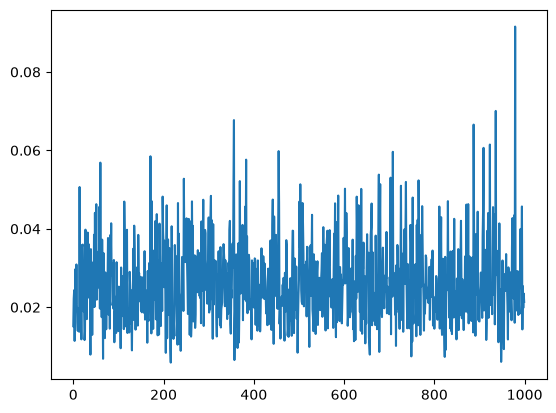

In [12]:
import matplotlib.pyplot as plt
import numpy as np

plt.plot([generation['fitness'] for generation in history])

In [13]:
def plot_key_change(key):
    vals =[]
    for generation in history:
        gen_vals = np.mean([result[0][key] for result in generation['results']])
        vals.append(gen_vals)
    plt.plot(vals)
    plt.title(key)
    plt.show()

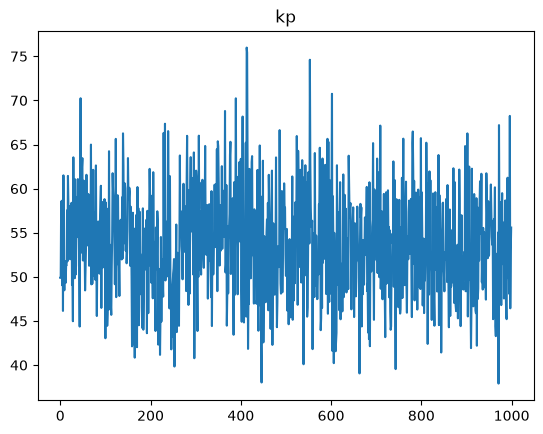

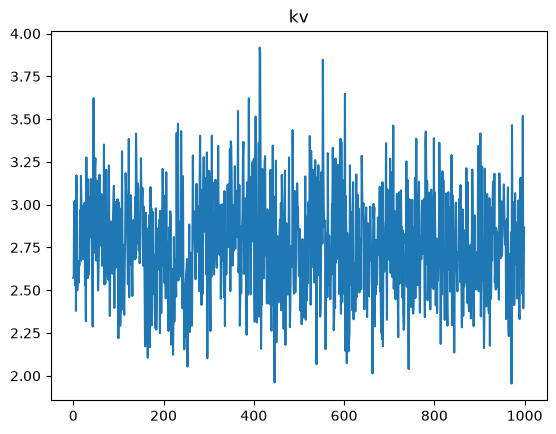

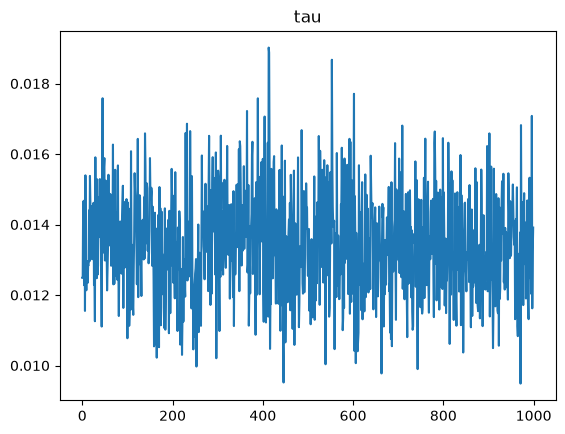

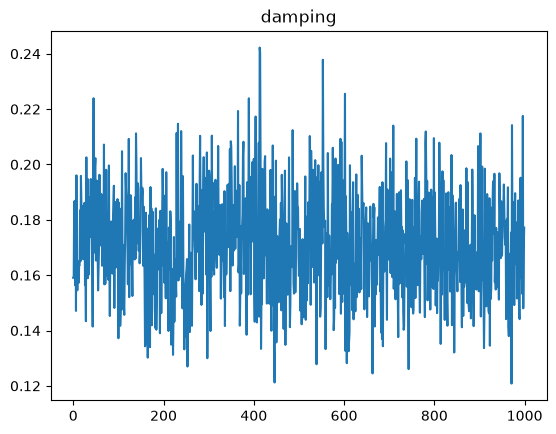

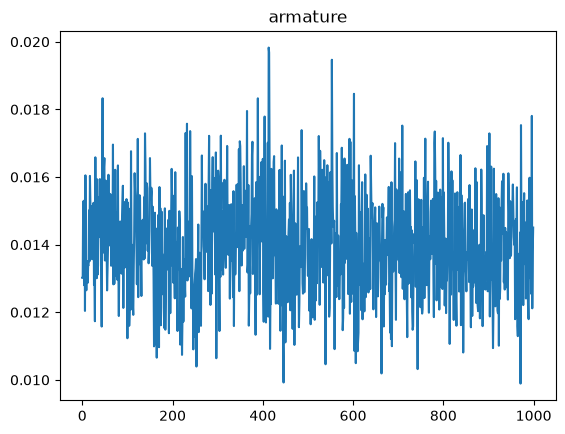

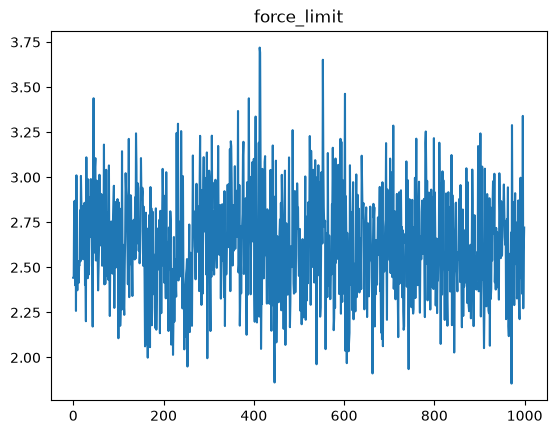

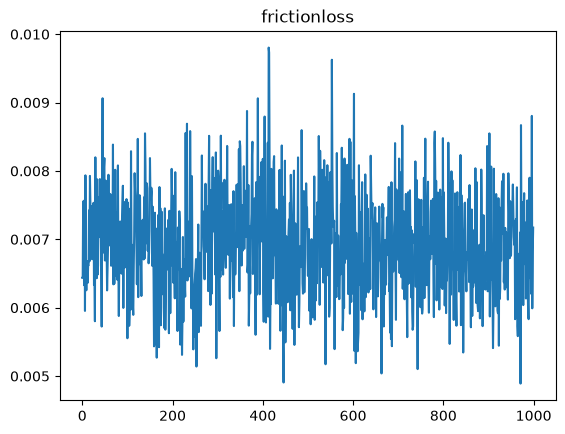

In [14]:
for key in ['kp', 'kv', 'tau', 'damping', 'armature', 'force_limit', 'frictionloss']:
# for key in ['tau']:
    plot_key_change(key)

In [ ]:
from sysid.data_interface import SysidDSInterface
from sysid.config import CONTROL_HZ
from sysid.env import Env
import time
import json
from tqdm import tqdm

params = {"kp": 55.16425524424094, "kv": 2.8441638016834414, "damping": 0.17584297702068546, "frictionloss": 0.007117351964407766, "armature": 0.014394006703957659, "force_limit": 8.40629855285546}
if __name__ == '__main__':
    ds = SysidDSInterface()
    env = Env(params=params)

    data = {
        'dataset': 'simulation',
        'config': ds.config,
        'data': [],
    }

    print(f'Collecting {len(ds)} rollouts...')
    pbar = tqdm(total=len(ds))

    for rollout in ds.iter_rollouts():
        pbar.update(1)
        env.reset()

        rollout_data = {
            'env_actions': [],
            'sensor_data': [],
        }
        for action in rollout['env_actions']:
            sensor_data = env.step(action)
            rollout_data['env_actions'].append(action)
            rollout_data['sensor_data'].append(sensor_data.tolist())

        data['data'].append(rollout_data)

    pbar.close()


In [16]:
rollouts = list(ds.iter_rollouts())

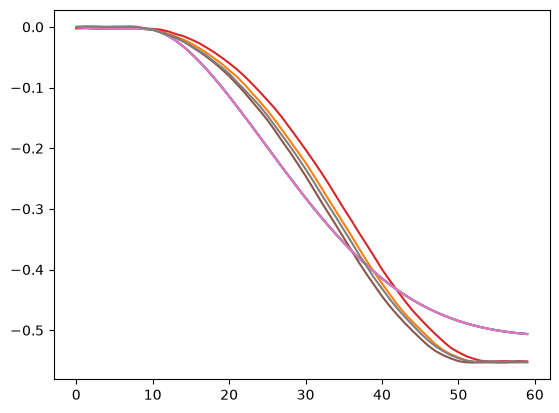

In [17]:
for sim_rollout, real_rollout in zip(data['data'], rollouts):
    plt.plot(sim_rollout['sensor_data'])
    plt.plot(real_rollout['sensor_data'])
    # plt.show()


In [ ]:
from sysid.data_interface import SysidDSInterface
from sysid.config import CONTROL_HZ
from sysid.env import Env
import time
import json
from tqdm import tqdm

# params = {"kp": 55.16425524424094, "kv": 2.8441638016834414, "damping": 0.17584297702068546, "frictionloss": 0.007117351964407766, "armature": 0.014394006703957659, "force_limit": 8.40629855285546}
# params = {"kp": 44.87924130639299, "kv": 2.313888096658114, "damping": 0.14305820613013226, "frictionloss": 0.00579036832562935, "armature": 0.011710338467774278, "force_limit": 2.19660269119488}
params = {"kp": 65.09022288972247, "kv": 3.355927764578723, "damping": 0.20748324285704314, "frictionloss": 0.008398011061633381, "armature": 0.01698398900680475, "force_limit": 3.1858238822248586}
if __name__ == '__main__':
    ds = SysidDSInterface()
    env = Env(params=params)

    data = {
        'dataset': 'simulation',
        'config': ds.config,
        'data': [],
    }

    print(f'Collecting {len(ds)} rollouts...')
    pbar = tqdm(total=len(ds))

    for rollout in ds.iter_rollouts():
        pbar.update(1)
        env.reset()

        rollout_data = {
            'env_actions': [],
            'sim_states': [],
            'real_states': [],
        }
        for action, real_state in zip(rollout['env_actions'], rollout['sensor_data']):
            sim_states = env.step(action)
            rollout_data['env_actions'].append(action)
            rollout_data['sim_states'].append(sim_states.tolist())
            rollout_data['real_states'].append(real_state)

        data['data'].append(rollout_data)

    pbar.close()

In [ ]:
len(rollout['env_actions'])

In [ ]:

for rollout in data['data']:
    fig, axs = plt.subplots(ncols=2)
    axs[0].plot(rollout['sim_states'])
    axs[0].plot(rollout['real_states'])
    axs[0].legend(['sim', 'real'])
    axs[1].plot(rollout['env_actions'])
    plt.show()